In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"D:\CreditCard-Fraud-Detection\data\fraud_detection_clean.csv")

print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print(df["is_fraud"].value_counts(normalize=True)*100)

Shape: (7194, 30)
Duplicate rows: 0
is_fraud
0    93.994996
1     6.005004
Name: proportion, dtype: float64


In [2]:
# month is constant (all transactions are from May 2026) -- carries no information
# flag_sum captures the interaction effect: fraud rate jumps from ~3% at 0 flags
# to ~37% at 3 flags, which is much stronger than any single flag alone

flag_cols = [
    "unusual_amount_flag", "velocity_flag", "new_device_flag",
    "location_change_flag", "night_transaction_flag"
]
df["flag_sum"] = df[flag_cols].sum(axis=1)

print(df.groupby("flag_sum")["is_fraud"].agg(["count", "mean"]))

          count      mean
flag_sum                 
0          3420  0.031871
1          2909  0.074596
2           789  0.101394
3            71  0.366197
4             5  0.000000


In [3]:
drop_columns = [
    "transaction_id",
    "user_id",
    "timestamp",
    "is_fraud",
    "month"   # constant column (all May 2026) -- carries no information
]

X = df.drop(columns=drop_columns)
y = df["is_fraud"]

print("Features shape:", X.shape)   # should now be (7194, 26)
print("Target shape:", y.shape)

Features shape: (7194, 26)
Target shape: (7194,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (5755, 26)
Testing features: (1439, 26)

Training target distribution:
is_fraud
0    5409
1     346
Name: count, dtype: int64

Testing target distribution:
is_fraud
0    1353
1      86
Name: count, dtype: int64


In [5]:
numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns.tolist()

print("Numerical features:")
print(numerical_cols)

print("\nCategorical features:")
print(categorical_cols)

print("\nNumber of numerical features:", len(numerical_cols))
print("Number of categorical features:", len(categorical_cols))

Numerical features:
['amount', 'transaction_frequency', 'avg_user_amount', 'deviation_from_avg', 'transaction_gap_seconds', 'account_age_days', 'failed_attempts', 'is_foreign_transaction', 'unusual_amount_flag', 'velocity_flag', 'new_device_flag', 'location_change_flag', 'night_transaction_flag', 'hour', 'day_of_week', 'is_weekend', 'is_night', 'log_amount', 'amount_to_avg_ratio', 'log_transaction_frequency', 'log_transaction_gap', 'flag_sum']

Categorical features:
['transaction_type', 'merchant_category', 'device_type', 'location']

Number of numerical features: 22
Number of categorical features: 4


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


LOGISTIC REGRESSION

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Create complete pipeline
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Train the model
logistic_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [8]:
y_pred = logistic_model.predict(X_test)

# Probability of fraud
y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")

print("\nFirst 10 predictions:")
print(y_pred[:10])

print("\nFirst 10 fraud probabilities:")
print(y_pred_proba[:10])

Predictions generated successfully!

First 10 predictions:
[1 0 1 0 1 1 0 1 0 0]

First 10 fraud probabilities:
[0.67059004 0.31625805 0.68789466 0.41738178 0.72066715 0.6177721
 0.49196087 0.60452685 0.26287289 0.18148587]


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print("========== LOGISTIC REGRESSION RESULTS ==========")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print(f"PR-AUC   : {pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

========== LOGISTIC REGRESSION RESULTS ==========
Accuracy : 0.6456
Precision: 0.0939
Recall   : 0.5698
F1 Score : 0.1612
ROC-AUC  : 0.6840
PR-AUC   : 0.1191

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.65      0.78      1353
           1       0.09      0.57      0.16        86

    accuracy                           0.65      1439
   macro avg       0.53      0.61      0.47      1439
weighted avg       0.91      0.65      0.74      1439


Confusion Matrix:
[[880 473]
 [ 37  49]]


RANDOM FOREST

In [10]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])


random_forest_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [11]:
rf_pred = random_forest_model.predict(X_test)
rf_pred_proba = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully!")

print("\nFirst 10 predictions:")
print(rf_pred[:10])

print("\nFirst 10 fraud probabilities:")
print(rf_pred_proba[:10])

Random Forest predictions generated successfully!

First 10 predictions:
[0 0 1 0 1 0 0 1 0 0]

First 10 fraud probabilities:
[0.44123617 0.29300575 0.56779819 0.45335842 0.5098181  0.41601566
 0.43769224 0.5771658  0.16536916 0.08621583]


In [12]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_pred_proba)
rf_pr_auc = average_precision_score(y_test, rf_pred_proba)

print("========== RANDOM FOREST RESULTS ==========")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")
print(f"PR-AUC   : {rf_pr_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

========== RANDOM FOREST RESULTS ==========
Accuracy : 0.6908
Precision: 0.0966
Recall   : 0.5000
F1 Score : 0.1620
ROC-AUC  : 0.6595
PR-AUC   : 0.1347

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.70      0.81      1353
           1       0.10      0.50      0.16        86

    accuracy                           0.69      1439
   macro avg       0.53      0.60      0.49      1439
weighted avg       0.91      0.69      0.77      1439


Confusion Matrix:
[[951 402]
 [ 43  43]]


In [13]:
# ==========================================
# RANDOM FOREST THRESHOLD ANALYSIS
# ==========================================

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Threshold | Precision | Recall | F1 Score")
print("-" * 45)

for threshold in thresholds:
    threshold_pred = (rf_pred_proba >= threshold).astype(int)

    precision = precision_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        threshold_pred,
        zero_division=0
    )

    print(
        f"{threshold:8.2f} | "
        f"{precision:9.4f} | "
        f"{recall:6.4f} | "
        f"{f1:8.4f}"
    )

Threshold | Precision | Recall | F1 Score
---------------------------------------------
    0.10 |    0.0601 | 1.0000 |   0.1135
    0.15 |    0.0634 | 1.0000 |   0.1193
    0.20 |    0.0642 | 0.9767 |   0.1205
    0.25 |    0.0642 | 0.9651 |   0.1204
    0.30 |    0.0671 | 0.9419 |   0.1252
    0.35 |    0.0735 | 0.8721 |   0.1355
    0.40 |    0.0785 | 0.7326 |   0.1417
    0.45 |    0.0928 | 0.6628 |   0.1629
    0.50 |    0.0966 | 0.5000 |   0.1620


In [14]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["precision", "recall", "f1", "roc_auc", "average_precision"]

models_to_check = {
    "Logistic Regression": logistic_model,
    "Random Forest": random_forest_model,
}

for name, pipeline in models_to_check.items():
    results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f"\n{name} (5-fold CV):")
    for metric in scoring:
        vals = results[f"test_{metric}"]
        print(f"  {metric:20s}: {vals.mean():.4f} (+/- {vals.std():.4f})")


Logistic Regression (5-fold CV):
  precision           : 0.0982 (+/- 0.0060)
  recall              : 0.5809 (+/- 0.0413)
  f1                  : 0.1680 (+/- 0.0103)
  roc_auc             : 0.6693 (+/- 0.0182)
  average_precision   : 0.1207 (+/- 0.0115)

Random Forest (5-fold CV):
  precision           : 0.0944 (+/- 0.0057)
  recall              : 0.4976 (+/- 0.0284)
  f1                  : 0.1586 (+/- 0.0090)
  roc_auc             : 0.6459 (+/- 0.0200)
  average_precision   : 0.1178 (+/- 0.0170)


GRADIENT BOOSTING MODEL

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))])

gb_model.fit(X_train, y_train)
print("Gradient Boosting model trained successfully!")

Gradient Boosting model trained successfully!


In [16]:
gb_pred = gb_model.predict(X_test)
gb_pred_proba = gb_model.predict_proba(X_test)[:, 1]

gb_accuracy = accuracy_score(y_test, gb_pred)
gb_precision = precision_score(y_test, gb_pred)
gb_recall = recall_score(y_test, gb_pred)
gb_f1 = f1_score(y_test, gb_pred)
gb_roc_auc = roc_auc_score(y_test, gb_pred_proba)
gb_pr_auc = average_precision_score(y_test, gb_pred_proba)

print("========== GRADIENT BOOSTING RESULTS ==========")
print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision : {gb_precision:.4f}")
print(f"Recall : {gb_recall:.4f}")
print(f"F1-Score : {gb_f1:.4f}")
print(f"ROC-AUC : {gb_roc_auc:.4f}")
print(f"PR-AUC : {gb_pr_auc:.4f}")

========== GRADIENT BOOSTING RESULTS ==========
Accuracy : 0.9409
Precision : 0.6000
Recall : 0.0349
F1-Score : 0.0659
ROC-AUC : 0.6842
PR-AUC : 0.1696


In [17]:
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Threshold | Precision | Recall | F1 Score")
print("-" * 45)

for threshold in thresholds:
    threshold_pred = (gb_pred_proba >= threshold).astype(int)
    p = precision_score(y_test, threshold_pred, zero_division=0)
    r = recall_score(y_test, threshold_pred, zero_division=0)
    f1 = f1_score(y_test, threshold_pred, zero_division=0)
    print(f"{threshold:8.2f} | {p:9.4f} | {r:8.4f} | {f1:8.4f}")

Threshold | Precision | Recall | F1 Score
---------------------------------------------
    0.05 |    0.0917 |   0.6977 |   0.1622
    0.10 |    0.1613 |   0.2326 |   0.1905
    0.15 |    0.2245 |   0.1279 |   0.1630
    0.20 |    0.3226 |   0.1163 |   0.1709
    0.25 |    0.4211 |   0.0930 |   0.1524
    0.30 |    0.4444 |   0.0930 |   0.1538
    0.35 |    0.3846 |   0.0581 |   0.1010
    0.40 |    0.3333 |   0.0349 |   0.0632
    0.45 |    0.4286 |   0.0349 |   0.0645
    0.50 |    0.6000 |   0.0349 |   0.0659


                           feature  importance
21                   num__flag_sum    0.127614
19  num__log_transaction_frequency    0.069288
1       num__transaction_frequency    0.067684
3          num__deviation_from_avg    0.061404
2             num__avg_user_amount    0.059252
9               num__velocity_flag    0.053267
20        num__log_transaction_gap    0.052559
4     num__transaction_gap_seconds    0.051339
0                      num__amount    0.047825
17                 num__log_amount    0.046616
18        num__amount_to_avg_ratio    0.044583
5            num__account_age_days    0.044104
7      num__is_foreign_transaction    0.040121
33             cat__location_India    0.038606
13                       num__hour    0.031041


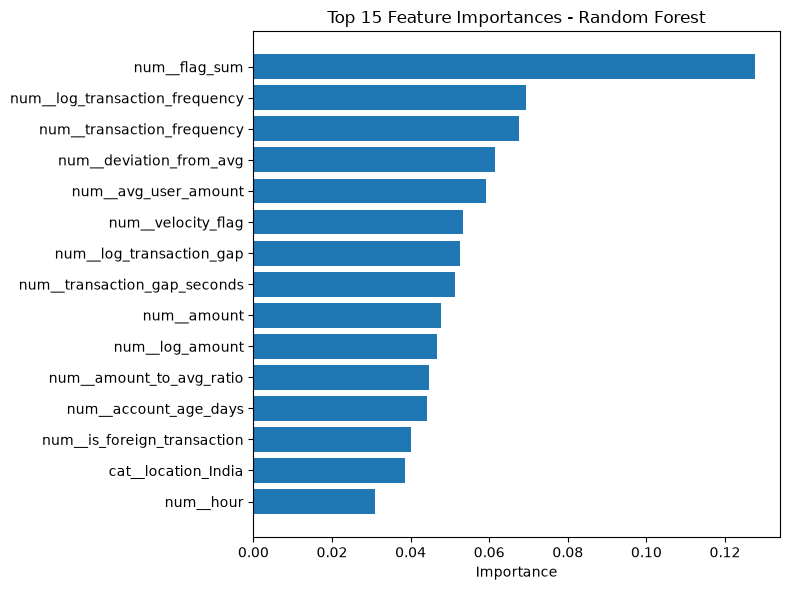

In [18]:
# FEATURE IMPORTANCE (Random Forest)
import matplotlib.pyplot as plt

feature_names = random_forest_model.named_steps["preprocessor"].get_feature_names_out()
importances = random_forest_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(15)

print(importance_df)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances - Random Forest")
plt.tight_layout()
plt.show()

In [19]:
# ==========================================
# SAVE FINAL MODEL WITH THRESHOLD
# ==========================================

import joblib

FINAL_THRESHOLD = 0.05   # chosen for recall priority: catches ~70% of fraud

final_package = {
    "model": gb_model,
    "threshold": FINAL_THRESHOLD,
    "metrics_at_threshold": {
        "precision": 0.0917,
        "recall": 0.6977,
        "f1": 0.1622,
    },
    "feature_columns": list(X.columns),   # exact column order/names the model expects
}

joblib.dump(final_package, r"D:\CreditCard-Fraud-Detection\models\final_fraud_model.joblib")
print("Model + threshold saved.")

Model + threshold saved.


In [20]:
# Save the model you decide is best (swap gb_model for whichever wins)
import joblib

joblib.dump(gb_model, r"D:\CreditCard-Fraud-Detection\models\final_fraud_model.joblib")
print("Model saved.")

Model saved.
